# UN M7 v14 fixed-parameter model

This notebook is a fixed-parameter model runner. The parameter values are written explicitly below, then the solver is run and plotted.

## Main balance equations

Matrix gas, bulk-bubble gas, and dislocation-bubble gas are advanced through the reduced exchange system

$$
\frac{dc}{dt}=S_c-g_b c-g_d c+b_b^{gas}m_b+b_d^{gas}m_d+D_g\nabla^2c
$$

$$
\frac{dm_b}{dt}=S_b+g_b c-b_b^{gas}m_b
$$

$$
\frac{dm_d}{dt}=S_d+g_d c-b_d^{gas}m_d
$$

For the fixed v14 `capture_only` setup used here:

$$
S_c=\beta,\qquad S_b=0,\qquad S_d=0
$$

so bulk nucleation mass coupling is off. Gas re-solution population factors are also off in this setup:

$$
b_b^{gas}=b_b,\qquad b_d^{gas}=b_d
$$

rather than $b_i^{gas}=b_i\phi_i$.

The bulk-bubble number density is

$$
\frac{dN_b}{dt}=\nu_b-b_b\phi_bN_b
$$

and dislocation-bubble coalescence is active:

$$
N_d^{n+1}=\frac{N_d^n}{1+s_{coal}\,4\lambda_d N_d^n\Delta V_d^+}
$$

Bulk-to-dislocation capture is also active:

$$
f_{cap}=\min\left(1,\max\left(0,s_{cap}N_d\,4\pi(R_d+R_b)^2\Delta R_d^+\right)\right)
$$

The v14 dislocation density law is

$$
\rho_d(F,T)=\rho_{scale}\max\left(\rho_{fab}, C_1\max(F-F_0,0)\right)f_T^{sat}(T)
$$

with the saturating Ray-Blank temperature factor normalized at 1025 K.

In [1]:
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import math

import matplotlib.pyplot as plt

HERE = Path.cwd()
for parent in [HERE, *HERE.parents]:
    if (parent / 'UN_model' / 'optuna' / 'M7_v14').exists():
        MODEL_DIR = parent / 'UN_model' / 'optuna' / 'M7_v14'
        break
else:
    MODEL_DIR = HERE

PLOTS_DIR = MODEL_DIR / 'fixed_parameter_plots'
PLOTS_DIR.mkdir(exist_ok=True)
print(f'Model folder: {MODEL_DIR}')
print(f'Plot folder:  {PLOTS_DIR}')

Model folder: /home/destro/sciantix-official/UN_model/optuna/M7_v14
Plot folder:  /home/destro/sciantix-official/UN_model/optuna/M7_v14/fixed_parameter_plots


In [2]:
# USER CONFIGURATION
# ============================================================

RANDOM_SEED = 123

# Compact by default. Increase only after checking that the pipeline works.
N_GLOBAL_FAST = 64
N_TOP_FINAL = 6
PLOT_TOP_N = 3

FAST_DT_H = 12.0
FAST_N_MODES = 22

FINAL_DT_H = 1.0
FINAL_N_MODES = 40

SAVE_FIGS = True
SHOW_PLOTS = False  # safer for WSL; plots are saved as PNGs
RESUME_FAST = True

# Score weights. Pressure is deliberately weak: it is a sanity term, not the main calibration target.
W_SWELLING = 1.00
W_RD = 0.60
W_ND_LEVEL = 0.65
W_ND_DROP = 1.00
W_PRESSURE = 0.20   # pressure is a physical sanity term; penalizes large p/p_eq deviations
W_FDOT_PRIOR = 0.25
W_RIZK_GAS_SHAPE = 0.08
W_HIGHT_GUARD = 0.08

# Model family switches for this fixed run.
MODEL_FAMILY = "M7_full"
USE_PHI_GAS_RESOLUTION = True       # phi multiplies gas re-solution terms only
USE_NUCLEATION_MASS_COUPLING = True # source_c=beta-2nu, source_mb=2nu
USE_BULK_DISLOCATION_CAPTURE = True # Barani-like linear clipped capture
PRESSURE_FREE_FACTOR = 3.0          # no pressure penalty inside [1/3, 3] for p/p_eq

# Fixed constants / nominal Rizk values
GRAIN_RADIUS = 6.0e-6       # m
XE_YIELD = 0.24             # Xe atoms/fission
GAMMA_B = 1.11              # J/m2
OMEGA_FG = 8.5e-29          # m3
LATTICE_PARAMETER = 4.889e-10

FISSION_RATE_NOMINAL = 5.0e19
F_N_NOMINAL = 1.0e-6
K_D_NOMINAL = 5.0e5
RHO_D_NOMINAL = 3.0e13

# ============================================================
# GLOBAL COMPACT PARAMETER RANGES
# ============================================================
# These are sampled with a simple Latin-hypercube-like method, implemented without scipy.
# Keep fission rate close to nominal by default.

PARAM_RANGES = {
    # name: (low, high, scale)
    "f_n":                 (1.0e-8, 1.0e-6, "log"),
    "K_d":                 (1.5e5, 1.0e6, "log"),
    "rho_d":               (1.0e13, 8.0e13, "log"),
    "fission_rate":        (4.0e19, 6.0e19, "linear"),
    "Dv_scale":            (0.2, 3.0, "log"),
    "Dg_scale":            (0.3, 3.0, "log"),
    "D2_xe_scale":         (0.1, 10.0, "log"),
    "b_scale":             (0.2, 5.0, "log"),
    "gb_scale":            (0.2, 5.0, "log"),
    "gd_scale":            (0.2, 8.0, "log"),
    "coalescence_d_scale": (0.3, 10.0, "log"),  # never zero
    "capture_scale":       (0.3, 3.0, "log"),   # no zero in this sweep
}

PARAM_NAMES = list(PARAM_RANGES.keys())

# Main diagnostic plotting grids
TEMPS_MAIN = [float(T) for T in range(900, 2001, 50)]
TEMPS_GAS_PARTITION = [float(T) for T in range(900, 2601, 100)]
BURNUPS = [1.1, 1.3, 3.2]

# ============================================================
# DIGITIZED EXPERIMENTAL POINTS
# ============================================================

EXP_SWELLING_T = [
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1127.0, "swelling": 0.68},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1228.0, "swelling": 0.59},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1312.0, "swelling": 0.43},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1402.0, "swelling": 0.58},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1485.0, "swelling": 1.22},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1549.0, "swelling": 1.84},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1598.0, "swelling": 1.66},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1632.0, "swelling": 2.13},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1669.0, "swelling": 3.60},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1685.0, "swelling": 2.72},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 899.0,  "swelling": 0.63},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1154.0, "swelling": 1.17},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1228.0, "swelling": 1.08},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1325.0, "swelling": 1.28},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1435.0, "swelling": 1.32},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1514.0, "swelling": 2.10},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1570.0, "swelling": 2.72},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1608.0, "swelling": 2.91},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1635.0, "swelling": 3.28},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1656.0, "swelling": 3.75},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1044.0, "swelling": 1.11},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1220.0, "swelling": 1.22},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1377.0, "swelling": 1.33},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1534.0, "swelling": 2.83},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1595.0, "swelling": 3.53},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1639.0, "swelling": 3.86},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1661.0, "swelling": 2.45},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1709.0, "swelling": 2.93},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1724.0, "swelling": 3.15},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 984.0,  "swelling": 0.72},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1056.0, "swelling": 1.06},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1126.0, "swelling": 1.26},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1247.0, "swelling": 1.58},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1343.0, "swelling": 1.79},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1420.0, "swelling": 2.08},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1459.0, "swelling": 2.40},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1511.0, "swelling": 2.83},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1557.0, "swelling": 3.31},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1590.0, "swelling": 3.75},
]

EXP_SWELLING_BURNUP_1600 = [
    {"burnup": 1.12, "swelling": 1.64, "series": "approx 100 kW/m"},
    {"burnup": 1.11, "swelling": 2.90, "series": "approx 119 kW/m"},
    {"burnup": 1.31, "swelling": 3.51, "series": "measurement"},
    {"burnup": 3.18, "swelling": 3.72, "series": "measurement"},
]

EXP_ND_T_13 = [
    {"T": 1153.0, "N": 5.22e19}, {"T": 1202.0, "N": 3.69e19},
    {"T": 1227.0, "N": 3.00e19}, {"T": 1235.0, "N": 3.57e19},
    {"T": 1248.0, "N": 2.44e19}, {"T": 1330.0, "N": 2.90e19},
    {"T": 1338.0, "N": 4.10e19}, {"T": 1377.0, "N": 2.71e19},
    {"T": 1408.0, "N": 1.67e19}, {"T": 1427.0, "N": 1.85e19},
    {"T": 1493.0, "N": 3.00e19}, {"T": 1507.0, "N": 2.44e19},
    {"T": 1524.0, "N": 1.56e19}, {"T": 1538.0, "N": 7.54e18},
    {"T": 1555.0, "N": 7.80e18}, {"T": 1561.0, "N": 1.92e19},
    {"T": 1599.0, "N": 5.34e18}, {"T": 1622.0, "N": 7.80e18},
    {"T": 1628.0, "N": 1.73e19}, {"T": 1649.0, "N": 5.34e18},
    {"T": 1656.0, "N": 3.65e18}, {"T": 1656.0, "N": 2.41e18},
    {"T": 1669.0, "N": 1.96e18}, {"T": 1682.0, "N": 2.44e19},
    {"T": 1685.0, "N": 1.40e19}, {"T": 1723.0, "N": 7.70e17},
    {"T": 1742.0, "N": 1.02e18}, {"T": 1739.0, "N": 1.65e18},
]

EXP_RD_T_13 = [
    {"T": 1045.0, "R_nm": 54.06}, {"T": 1219.0, "R_nm": 60.37},
    {"T": 1374.0, "R_nm": 69.58}, {"T": 1535.0, "R_nm": 104.85},
    {"T": 1594.0, "R_nm": 120.83}, {"T": 1641.0, "R_nm": 143.73},
    {"T": 1663.0, "R_nm": 122.76}, {"T": 1710.0, "R_nm": 157.99},
    {"T": 1725.0, "R_nm": 173.67},
]

# ============================================================
# MODEL PARAMETERS
# ============================================================

@dataclass(frozen=True)
class Candidate:
    label: str
    f_n: float
    K_d: float
    rho_d: float
    fission_rate: float

    # Backward-compatible aggregate scales. In this fixed v14 run they stay at 1.0,
    # while the split scales below carry the calibrated parameter values.
    Dv_scale: float = 1.0
    Dv_D1_scale: float = 1.0
    Dv_D2_scale: float = 1.0
    Dg_scale: float = 1.0
    b_scale: float = 1.0
    gb_scale: float = 1.0
    gd_scale: float = 1.0
    coalescence_d_scale: float = 1.0
    capture_scale: float = 1.0

    # Deprecated for v6: Xe D2 is computed only for diagnostics and is not used in D_g.
    D2_xe_scale: float = 1.0

    # v6 split gas diffusion: D_g = Dg_scale * (Dg_D1_scale*D1 + Dg_D3_scale*D3)
    Dg_D1_scale: float = 1.0
    Dg_D3_scale: float = 1.0

    # v6 split vacancy diffusion: D_v = Dv_scale * (Dv_D1_scale*D1 + Dv_D2_scale*D2)
    Dv_D1_scale: float = 1.0
    Dv_D2_scale: float = 1.0

    # v6 split re-solution.
    b_bulk_scale: float = 1.0
    b_dislocation_scale: float = 1.0

    # v6 split dislocation trapping.
    gd_bubble_scale: float = 1.0
    gd_line_scale: float = 1.0
    # alpha=1: current free-dislocation correction rho_d - 2 R_d N_d.
    # alpha=0: Barani-like full line sink rho_d.
    gd_line_alpha: float = 1.0


@dataclass
class UNParameters:
    temperature: float = 1600.0
    fission_rate: float = FISSION_RATE_NOMINAL
    grain_radius: float = GRAIN_RADIUS
    target_burnup_percent_fima: Optional[float] = None
    final_time: float = 24.0 * 3600.0
    dt: float = FAST_DT_H * 3600.0
    n_modes: int = FAST_N_MODES

    xe_yield: float = XE_YIELD
    precursor_factor: float = 1.0

    # Xe diffusivity: D1 + D2 + D3 (Rizk Table 2).
    D10: float = 1.56e-3
    Q1: float = 4.94
    A20_xe: float = 1.21e-67
    B21_xe: float = 25.87
    B22_xe: float = -1.49
    B23_xe: float = 0.0
    A30: float = 1.85e-39
    D2_xe_scale: float = 1.0  # deprecated in v6; kept for compatibility/diagnostics
    Dg_scale: float = 1.0
    Dg_D1_scale: float = 1.0
    Dg_D3_scale: float = 1.0

    kB_eV: float = 8.617333262e-5
    kB_J: float = 1.380649e-23

    # Vacancy diffusivity: refit previously obtained from Rizk Fig. 4.
    D10_vU: float = 1.35e-2
    Q1_vU: float = 5.66
    B21_vU_refit: float = -0.62
    B22_vU_refit: float = -0.04
    A20_vU_fig4_refit: float = 4.6304523933553033e-29
    Dv_scale: float = 1.0
    Dv_D1_scale: float = 1.0
    Dv_D2_scale: float = 1.0

    radius_in_lattice: float = 0.21e-9
    omega_fg: float = OMEGA_FG
    lattice_parameter: float = LATTICE_PARAMETER
    gamma_b: float = GAMMA_B
    hydrostatic_stress: float = 0.0
    min_radius_for_pressure: float = 1.0e-15

    f_n: float = F_N_NOMINAL
    rho_d: float = RHO_D_NOMINAL
    K_d: float = K_D_NOMINAL
    r_d: float = 3.46e-10
    Z_d: float = 5.0

    Dg_extra_scale: float = 1.0
    gb_scale: float = 1.0
    gd_scale: float = 1.0
    b_scale: float = 1.0
    b_bulk_scale: float = 1.0
    b_dislocation_scale: float = 1.0
    gd_bubble_scale: float = 1.0
    gd_line_scale: float = 1.0
    gd_line_alpha: float = 1.0
    coalescence_d_scale: float = 1.0
    capture_scale: float = 1.0

    R_b: float = 0.0
    N_b: float = 0.0
    R_d: float = 0.0
    N_d: Optional[float] = None
    c0: float = 0.0
    mb0: float = 0.0
    md0: float = 0.0
    nvb0: Optional[float] = None
    nvd0: Optional[float] = None

    bulk_seed_radius_nm: float = 0.0
    vacancy_absorption_only: bool = True
    update_bulk_vacancies: bool = True
    min_number_density: float = 0.0
    min_volume: float = 0.0

    def __post_init__(self):
        if self.N_d is None:
            self.N_d = self.K_d * self.rho_d
        if self.target_burnup_percent_fima is not None:
            self.final_time = burnup_percent_to_time(
                self.target_burnup_percent_fima,
                self.fission_rate,
                self.lattice_parameter,
            )

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def omega_matrix(p: UNParameters) -> float:
    return p.lattice_parameter**3 / 4.0


def uranium_atom_density_from_lattice(lattice_parameter: float) -> float:
    return 4.0 / lattice_parameter**3


def burnup_percent_to_time(burnup_percent_fima: float, fission_rate: float, lattice_parameter: float) -> float:
    if fission_rate <= 0.0:
        raise ValueError("fission_rate must be positive")
    return (burnup_percent_fima / 100.0) * uranium_atom_density_from_lattice(lattice_parameter) / fission_rate


def time_to_burnup_percent(time: float, fission_rate: float, lattice_parameter: float) -> float:
    return 100.0 * fission_rate * time / uranium_atom_density_from_lattice(lattice_parameter)


def sphere_volume(R: float) -> float:
    return 0.0 if R <= 0.0 else (4.0 / 3.0) * math.pi * R**3


def radius_from_volume(V: float) -> float:
    return 0.0 if V <= 0.0 else (3.0 * V / (4.0 * math.pi)) ** (1.0 / 3.0)


def xe_diffusivity_UN(p: UNParameters):
    T = p.temperature
    kBT = p.kB_eV * T
    D1 = p.D10 * math.exp(-p.Q1 / kBT)
    # Irradiation-enhanced Xe diffusivity. Rizk notes it is usually small,
    # but it is kept explicitly here instead of being set to zero.
    try:
        expo = (
            -p.B21_xe / kBT
            -p.B22_xe / (kBT**2)
            -p.B23_xe / (kBT**3)
        )
        # avoid numerical overflow if parameter ranges are later modified
        expo = max(min(expo, 700.0), -745.0)
        D2 = math.sqrt(p.fission_rate) * p.A20_xe * math.exp(expo)
    except OverflowError:
        D2 = math.inf
    D3 = p.A30 * p.fission_rate

    # v6 decision: do not calibrate/use Xe D2 in D_g because Rizk reports it as negligible
    # for Xe compared with D1 + D3.  D2 is still returned as a diagnostic.
    Dg_unscaled = p.Dg_D1_scale * D1 + p.Dg_D3_scale * D3
    Dg = Dg_unscaled * p.Dg_scale * p.precursor_factor * p.Dg_extra_scale
    return Dg, {
        "D1_Xe": D1,
        "D2_Xe": D2,
        "D2_Xe_scaled": 0.0,
        "D3_Xe": D3,
        "Dg_D1_scaled": p.Dg_D1_scale * D1,
        "Dg_D3_scaled": p.Dg_D3_scale * D3,
        "D2_Xe_over_Dg_unscaled": (D2 / Dg_unscaled) if Dg_unscaled > 0 and math.isfinite(Dg_unscaled) else math.nan,
        "Dg": Dg,
    }


def vacancy_diffusivity_UN(p: UNParameters):
    T = p.temperature
    kBT = p.kB_eV * T
    D1 = p.D10_vU * math.exp(-p.Q1_vU / kBT)
    D2 = math.sqrt(p.fission_rate) * p.A20_vU_fig4_refit * math.exp(
        p.B21_vU_refit / kBT + p.B22_vU_refit / (kBT**2)
    )
    Dv_unscaled = p.Dv_D1_scale * D1 + p.Dv_D2_scale * D2
    Dv = Dv_unscaled * p.Dv_scale
    return Dv, {
        "Dv1": D1,
        "Dv2": D2,
        "Dv1_scaled": p.Dv_D1_scale * D1,
        "Dv2_scaled": p.Dv_D2_scale * D2,
        "Dv": Dv,
    }


def b0_resolution(R: float) -> float:
    R = max(R, 1.0e-15)
    return 1.0e-25 * (2.64 - 2.02 * math.exp(-2.61e-9 / R))


def resolution_rates_UN(p: UNParameters, R_b: float, R_d: float):
    # v6: split bulk and dislocation re-solution scale factors.
    # b_scale is kept as a backward-compatible common multiplier.
    b_b = p.fission_rate * b0_resolution(R_b + p.radius_in_lattice) * p.b_scale * p.b_bulk_scale
    b_d = p.fission_rate * b0_resolution(R_d + p.radius_in_lattice) * p.b_scale * p.b_dislocation_scale
    return b_b, b_d


def trapping_rates_UN(p: UNParameters, Dg: float, R_b: float, N_b: float, R_d: float, N_d: float):
    Rb_eff = R_b + p.radius_in_lattice
    Rd_eff = R_d + p.radius_in_lattice
    g_b_unscaled = 0.0 if N_b <= 0.0 else 4.0 * math.pi * Dg * Rb_eff * N_b

    Gamma_d = 1.0 / math.sqrt(math.pi * p.rho_d)
    den = math.log(Gamma_d / (p.Z_d * p.r_d)) - 3.0 / 5.0
    if den <= 0.0:
        raise ValueError(f"Invalid dislocation sink denominator: {den:g}")

    # v6: split dislocation trapping into bubble sink and line sink.
    # gd_line_alpha=1 reproduces the previous correction rho_d - 2 R_d N_d.
    # gd_line_alpha=0 gives a Barani-like full line sink rho_d.
    free_dislocation = max(p.rho_d - p.gd_line_alpha * 2.0 * R_d * N_d, 0.0)
    term_bubbles = 4.0 * math.pi * Dg * Rd_eff * N_d
    term_dislocation = (2.0 * math.pi * Dg / den) * free_dislocation
    g_d_unscaled = p.gd_bubble_scale * term_bubbles + p.gd_line_scale * term_dislocation

    g_b = p.gb_scale * g_b_unscaled
    g_d = p.gd_scale * g_d_unscaled

    return g_b, g_d, {
        "Gamma_d": Gamma_d,
        "den": den,
        "free_dislocation": free_dislocation,
        "term_bubbles": term_bubbles,
        "term_dislocation": term_dislocation,
        "term_bubbles_scaled": p.gd_bubble_scale * term_bubbles,
        "term_dislocation_scaled": p.gd_line_scale * term_dislocation,
        "g_b_unscaled": g_b_unscaled,
        "g_d_unscaled": g_d_unscaled,
    }


def beta_production(p: UNParameters) -> float:
    return p.xe_yield * p.fission_rate


def nucleation_rate_bulk(p: UNParameters, Dg: float, c: float) -> float:
    return 8.0 * math.pi * p.f_n * Dg * p.omega_fg ** (1.0 / 3.0) * max(c, 0.0) ** 2


def phi_population(m_gas: float, N: float) -> float:
    if N <= 0.0 or m_gas <= 0.0:
        return 0.0
    atoms_per_bubble = m_gas / N
    if atoms_per_bubble <= 1.0:
        return 0.0
    return 1.0 / (atoms_per_bubble - 1.0)


def coalescence_lambda(Vd: float, Nd: float) -> float:
    xi = max(0.0, min(Vd * Nd, 0.999999))
    return (2.0 - xi) / (2.0 * (1.0 - xi) ** 3)


def pressure_internal(p: UNParameters, m_gas: float, n_vac: float) -> float:
    if m_gas <= 0.0:
        return 0.0
    if n_vac <= 0.0:
        return math.inf
    denom = n_vac * omega_matrix(p)
    return math.inf if denom <= 0.0 else p.kB_J * p.temperature * m_gas / denom


def pressure_equilibrium(p: UNParameters, R: float) -> float:
    return 2.0 * p.gamma_b / max(R, p.min_radius_for_pressure) - p.hydrostatic_stress


def gas_only_radius_for_population(p: UNParameters, m_gas: float, N: float) -> float:
    if m_gas <= 0.0 or N <= 0.0:
        return 0.0
    return radius_from_volume(p.omega_fg * m_gas / N)


def radius_for_vacancy_update(p: UNParameters, R_old: float, N: float, m_gas: float) -> float:
    if R_old > 0.0:
        return R_old
    return gas_only_radius_for_population(p, m_gas, N)


def wigner_seitz_delta(N: float) -> float:
    return (3.0 / (4.0 * math.pi * max(N, 1.0))) ** (1.0 / 3.0)


def zeta_geometry(R: float, N: float) -> float:
    delta = wigner_seitz_delta(N)
    psi = max(R / delta, 1.0e-12)
    den = -psi**6 + 5.0 * psi**2 - 9.0 * psi + 5.0
    den = max(den, 1.0e-30)
    return max(10.0 * psi * (1.0 + psi**3) / den, 1.0e-30)


def vacancy_concentration_implicit_step(p: UNParameters, Dv: float, R: float, N: float, m_gas: float, n_old: float, dt: float):
    if N <= 0.0 or m_gas <= 0.0:
        return n_old, 0.0
    R_update = radius_for_vacancy_update(p, R, N, m_gas)
    if R_update <= 0.0:
        return n_old, 0.0

    p_eq = 2.0 * p.gamma_b / R_update - p.hydrostatic_stress
    p_int_old = pressure_internal(p, m_gas, n_old)

    if p.vacancy_absorption_only and p_int_old <= p_eq:
        return n_old, 0.0

    delta = wigner_seitz_delta(N)
    zeta = zeta_geometry(R_update, N)
    A = 2.0 * math.pi * Dv * delta * N / (p.kB_J * p.temperature * zeta)
    C = p.kB_J * p.temperature * m_gas / omega_matrix(p)
    B = n_old - dt * A * p_eq
    disc = B * B + 4.0 * dt * A * C

    if disc < 0.0:
        raise ValueError(f"Negative discriminant in vacancy step: {disc:g}")

    sqrt_disc = math.sqrt(disc)
    if B >= 0.0:
        n_new = 0.5 * (B + sqrt_disc)
    else:
        denom = sqrt_disc - B
        n_new = 0.0 if denom <= 0.0 else (2.0 * dt * A * C) / denom

    if p.vacancy_absorption_only:
        n_new = max(n_new, n_old)

    return n_new, (n_new - n_old) / dt


def initialize_vacancy_concentration(p: UNParameters, N: float, R: float, m_gas: float) -> float:
    if N <= 0.0 or R <= 0.0:
        return 0.0
    vacancy_volume = max(N * sphere_volume(R) - p.omega_fg * m_gas, 0.0)
    return vacancy_volume / omega_matrix(p)


def initialize_modes_from_average(average: float, n_modes: int, n_iter: int = 20):
    modes = [0.0 for _ in range(n_modes)]
    projection_coeff = -math.sqrt(8.0 / math.pi)
    remainder = average
    for _ in range(n_iter):
        reconstructed = 0.0
        for i in range(n_modes):
            n = i + 1
            n_coeff = (-1.0) ** n / n
            modes[i] += projection_coeff * n_coeff * remainder
            reconstructed += projection_coeff * n_coeff * modes[i] * 3.0 / (4.0 * math.pi)
        remainder = average - reconstructed
    return modes


def reconstruct_average(modes: Sequence[float]) -> float:
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    average = 0.0
    for i, value in enumerate(modes):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        average += projection_coeff * n_coeff * value / ((4.0 / 3.0) * math.pi)
    return average


def det3(A):
    return (
        A[0][0] * (A[1][1] * A[2][2] - A[1][2] * A[2][1])
        - A[0][1] * (A[1][0] * A[2][2] - A[1][2] * A[2][0])
        + A[0][2] * (A[1][0] * A[2][1] - A[1][1] * A[2][0])
    )


def solve3x3_cramer(A, b):
    detA = det3(A)
    if abs(detA) < 1.0e-300:
        raise ZeroDivisionError("Singular 3x3 system")
    Ax = [[b[i], A[i][1], A[i][2]] for i in range(3)]
    Ay = [[A[i][0], b[i], A[i][2]] for i in range(3)]
    Az = [[A[i][0], A[i][1], b[i]] for i in range(3)]
    return [det3(Ax) / detA, det3(Ay) / detA, det3(Az) / detA]


def sciantix_3x3_exchange_step(
    modes_c,
    modes_mb,
    modes_md,
    Dg: float,
    R_grain: float,
    source_c: float,
    source_mb: float,
    source_md: float,
    g_b: float,
    g_d: float,
    b_b_gas: float,
    b_d_gas: float,
    dt: float,
):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    diffusion_rate_coeff = math.pi**2 * Dg / R_grain**2

    for i in range(len(modes_c)):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        diffusion_rate = diffusion_rate_coeff * n**2

        src_c = projection_coeff * source_c * n_coeff
        src_mb = projection_coeff * source_mb * n_coeff
        src_md = projection_coeff * source_md * n_coeff

        A = [
            [1.0 + (diffusion_rate + g_b + g_d) * dt, -b_b_gas * dt, -b_d_gas * dt],
            [-g_b * dt, 1.0 + b_b_gas * dt, 0.0],
            [-g_d * dt, 0.0, 1.0 + b_d_gas * dt],
        ]
        rhs = [
            modes_c[i] + src_c * dt,
            modes_mb[i] + src_mb * dt,
            modes_md[i] + src_md * dt,
        ]
        modes_c[i], modes_mb[i], modes_md[i] = solve3x3_cramer(A, rhs)

    return reconstruct_average(modes_c), reconstruct_average(modes_mb), reconstruct_average(modes_md)


def reset_modes_to_averages(c: float, mb: float, md: float, n_modes: int):
    return (
        initialize_modes_from_average(max(c, 0.0), n_modes),
        initialize_modes_from_average(max(mb, 0.0), n_modes),
        initialize_modes_from_average(max(md, 0.0), n_modes),
    )

# ============================================================
# SOLVER M7
# ============================================================

def solve_UN_M7(p: UNParameters, keep_history: bool = True):
    modes_c = initialize_modes_from_average(p.c0, p.n_modes)
    modes_mb = initialize_modes_from_average(p.mb0, p.n_modes)
    modes_md = initialize_modes_from_average(p.md0, p.n_modes)

    R_b = p.R_b
    R_d = p.R_d
    N_b = p.N_b
    N_d = p.N_d
    V_b = sphere_volume(R_b)
    V_d = sphere_volume(R_d)

    nvb = initialize_vacancy_concentration(p, N_b, R_b, p.mb0) if p.nvb0 is None else p.nvb0
    nvd = initialize_vacancy_concentration(p, N_d, R_d, p.md0) if p.nvd0 is None else p.nvd0

    beta = beta_production(p)
    initial_gas = p.c0 + p.mb0 + p.md0
    generated = 0.0
    q_gb = 0.0
    retained = initial_gas
    t = 0.0

    capture_fraction_sum = 0.0
    capture_raw_sum = 0.0
    capture_bubbles_cumulative = 0.0
    max_f_cap_step = 0.0

    hist_keys = [
        "time", "burnup_percent_fima", "c", "mb", "md", "Nb", "Nd", "Vb", "Vd", "Rb", "Rd",
        "nvb", "nvd", "generated", "retained", "q_gb", "swelling_b", "swelling_d", "swelling_ig",
        "p_b", "p_d", "p_b_eq", "p_d_eq", "lambda_d", "nu_b", "phi_b", "phi_d",
        "f_cap_step", "cap_raw_step", "capture_fraction_sum", "capture_raw_sum",
        "capture_bubbles_cumulative", "max_f_cap_step",
        "matrix_gas_percent", "bulk_gas_percent", "dislocation_gas_percent", "qgb_gas_percent",
    ]
    hist = {key: [] for key in hist_keys}

    def append_state(nu_b=0.0, phi_b=0.0, phi_d=0.0, lambda_d=0.0, fcap=0.0, capraw=0.0):
        if not keep_history:
            return
        c_av = reconstruct_average(modes_c)
        mb_av = reconstruct_average(modes_mb)
        md_av = reconstruct_average(modes_md)
        p_b = pressure_internal(p, mb_av, nvb)
        p_d = pressure_internal(p, md_av, nvd)
        p_b_eq = pressure_equilibrium(p, R_b)
        p_d_eq = pressure_equilibrium(p, R_d)

        hist["time"].append(t)
        hist["burnup_percent_fima"].append(time_to_burnup_percent(t, p.fission_rate, p.lattice_parameter))
        hist["c"].append(c_av)
        hist["mb"].append(mb_av)
        hist["md"].append(md_av)
        hist["Nb"].append(N_b)
        hist["Nd"].append(N_d)
        hist["Vb"].append(V_b)
        hist["Vd"].append(V_d)
        hist["Rb"].append(R_b)
        hist["Rd"].append(R_d)
        hist["nvb"].append(nvb)
        hist["nvd"].append(nvd)
        hist["generated"].append(generated)
        hist["retained"].append(retained)
        hist["q_gb"].append(q_gb)
        hist["swelling_b"].append(N_b * V_b)
        hist["swelling_d"].append(N_d * V_d)
        hist["swelling_ig"].append(N_b * V_b + N_d * V_d)
        hist["p_b"].append(p_b)
        hist["p_d"].append(p_d)
        hist["p_b_eq"].append(p_b_eq)
        hist["p_d_eq"].append(p_d_eq)
        hist["lambda_d"].append(lambda_d)
        hist["nu_b"].append(nu_b)
        hist["phi_b"].append(phi_b)
        hist["phi_d"].append(phi_d)
        hist["f_cap_step"].append(fcap)
        hist["cap_raw_step"].append(capraw)
        hist["capture_fraction_sum"].append(capture_fraction_sum)
        hist["capture_raw_sum"].append(capture_raw_sum)
        hist["capture_bubbles_cumulative"].append(capture_bubbles_cumulative)
        hist["max_f_cap_step"].append(max_f_cap_step)
        hist["matrix_gas_percent"].append(100.0 * c_av / generated if generated > 0.0 else 0.0)
        hist["bulk_gas_percent"].append(100.0 * mb_av / generated if generated > 0.0 else 0.0)
        hist["dislocation_gas_percent"].append(100.0 * md_av / generated if generated > 0.0 else 0.0)
        hist["qgb_gas_percent"].append(100.0 * q_gb / generated if generated > 0.0 else 0.0)

    append_state()
    last_rates = {}
    n_steps = int(math.ceil(p.final_time / p.dt))

    for _ in range(n_steps):
        dt = min(p.dt, p.final_time - t)
        if dt <= 0.0:
            break

        c_old = reconstruct_average(modes_c)
        mb_old = reconstruct_average(modes_mb)
        md_old = reconstruct_average(modes_md)

        Nb_old = N_b
        Nd_old = N_d
        Vd_old = V_d
        Rb_old = R_b
        Rd_old = R_d
        # v6 capture uses dR_d, so Vcap_old is not needed.

        Dg, D_parts = xe_diffusivity_UN(p)
        Dv, Dv_parts = vacancy_diffusivity_UN(p)
        b_b, b_d = resolution_rates_UN(p, R_b, R_d)
        g_b, g_d, trapping_parts = trapping_rates_UN(p, Dg, R_b, Nb_old, R_d, Nd_old)

        nu_b = nucleation_rate_bulk(p, Dg, c_old)
        phi_b = phi_population(mb_old, Nb_old)
        phi_d = phi_population(md_old, Nd_old)

        if USE_PHI_GAS_RESOLUTION:
            b_b_gas = b_b * phi_b
            b_d_gas = b_d * phi_d
        else:
            b_b_gas = b_b
            b_d_gas = b_d

        # N_b destruction uses original b_b * phi_b term.
        N_b = (Nb_old + dt * nu_b) / (1.0 + dt * b_b * phi_b)
        N_b = max(N_b, p.min_number_density)

        # Optional M7 gas mass coupling of bulk nucleation.
        if USE_NUCLEATION_MASS_COUPLING:
            source_c = beta - 2.0 * nu_b
            source_mb = 2.0 * nu_b
        else:
            source_c = beta
            source_mb = 0.0
        source_md = 0.0

        c_new, mb_new, md_new = sciantix_3x3_exchange_step(
            modes_c, modes_mb, modes_md,
            Dg, p.grain_radius,
            source_c, source_mb, source_md,
            g_b, g_d,
            b_b_gas, b_d_gas,
            dt,
        )

        if c_new < 0.0 or mb_new < 0.0 or md_new < 0.0:
            c_new = max(c_new, 0.0)
            mb_new = max(mb_new, 0.0)
            md_new = max(md_new, 0.0)
            modes_c, modes_mb, modes_md = reset_modes_to_averages(c_new, mb_new, md_new, p.n_modes)

        dmb_dt = (mb_new - mb_old) / dt
        dmd_dt = (md_new - md_old) / dt

        if p.update_bulk_vacancies:
            nvb, dnvb_dt = vacancy_concentration_implicit_step(p, Dv, R_b, N_b, mb_new, nvb, dt)
        else:
            dnvb_dt = 0.0
        nvd, dnvd_dt = vacancy_concentration_implicit_step(p, Dv, R_d, Nd_old, md_new, nvd, dt)

        if N_b > 0.0:
            V_b_growth = V_b + dt * (p.omega_fg / N_b * dmb_dt + omega_matrix(p) / N_b * dnvb_dt)
            V_b_growth = max(V_b_growth, p.min_volume)
        else:
            V_b_growth = 0.0

        if Nd_old > 0.0:
            dVd_growth_dt = p.omega_fg / Nd_old * dmd_dt + omega_matrix(p) / Nd_old * dnvd_dt
            V_d_growth = max(V_d + dt * dVd_growth_dt, p.min_volume)
        else:
            dVd_growth_dt = 0.0
            V_d_growth = 0.0

        # Dislocation-bubble coalescence: ON. Scale can vary but is never zero in candidate ranges.
        lambda_d = coalescence_lambda(Vd_old, Nd_old)
        dVd_positive = max(V_d_growth - Vd_old, 0.0)
        if dVd_positive > 0.0 and Nd_old > 0.0:
            denominator = 1.0 + p.coalescence_d_scale * 4.0 * lambda_d * Nd_old * dVd_positive
            N_d = Nd_old / denominator
        else:
            N_d = Nd_old
        N_d = max(N_d, p.min_number_density)

        # Reconstruct volumes after gas/vacancy update and dislocation coalescence.
        V_b = (p.omega_fg * max(mb_new, 0.0) + omega_matrix(p) * nvb) / N_b if N_b > 0.0 else 0.0
        V_d = (p.omega_fg * max(md_new, 0.0) + omega_matrix(p) * nvd) / N_d if N_d > 0.0 else 0.0
        V_b = max(V_b, p.min_volume)
        V_d = max(V_d, p.min_volume)
        R_b = radius_from_volume(V_b)
        R_d = radius_from_volume(V_d)

        # Bulk-dislocation capture: v6 Barani-like linear clipped step.
        # Barani uses dV*_d = 4*pi*(R_d + R_b)^2*dR_d.
        # The previous implementation used Delta[(R_d+R_b)^3], which also counted Delta R_b.
        # Here only the expansion of the dislocation bubble sweeps new capture volume.
        delta_Rd_cap = max(R_d - Rd_old, 0.0)
        delta_Vcap = 4.0 * math.pi * (Rd_old + Rb_old) ** 2 * delta_Rd_cap
        if USE_BULK_DISLOCATION_CAPTURE:
            cap_raw_step = p.capture_scale * N_d * delta_Vcap
            f_cap = max(0.0, min(cap_raw_step, 1.0))
        else:
            cap_raw_step = 0.0
            f_cap = 0.0

        capture_raw_sum += cap_raw_step
        capture_fraction_sum += f_cap
        max_f_cap_step = max(max_f_cap_step, f_cap)

        if f_cap > 0.0 and N_b > 0.0:
            mb_before = max(mb_new, 0.0)
            nvb_before = max(nvb, 0.0)
            captured_bubbles = f_cap * N_b

            mb_new = (1.0 - f_cap) * mb_before
            md_new = max(md_new, 0.0) + f_cap * mb_before
            nvb = (1.0 - f_cap) * nvb_before
            nvd = max(nvd, 0.0) + f_cap * nvb_before
            N_b = (1.0 - f_cap) * N_b

            capture_bubbles_cumulative += captured_bubbles

            modes_c, modes_mb, modes_md = reset_modes_to_averages(c_new, mb_new, md_new, p.n_modes)

            V_b = (p.omega_fg * max(mb_new, 0.0) + omega_matrix(p) * nvb) / N_b if N_b > 0.0 else 0.0
            V_d = (p.omega_fg * max(md_new, 0.0) + omega_matrix(p) * nvd) / N_d if N_d > 0.0 else 0.0
            V_b = max(V_b, p.min_volume)
            V_d = max(V_d, p.min_volume)
            R_b = radius_from_volume(V_b)
            R_d = radius_from_volume(V_d)

        generated += beta * dt
        retained = max(c_new, 0.0) + max(mb_new, 0.0) + max(md_new, 0.0)
        q_gb = max(initial_gas + generated - retained, 0.0)
        t += dt

        last_rates = {
            "Dg": Dg, "Dv": Dv, "beta": beta,
            "g_b": g_b, "g_d": g_d,
            "b_b": b_b, "b_d": b_d,
            "b_b_gas": b_b_gas, "b_d_gas": b_d_gas,
            "nu_b": nu_b, "phi_b": phi_b, "phi_d": phi_d,
            "lambda_d": lambda_d,
            "dVd_growth_dt": dVd_growth_dt,
            "dnvb_dt": dnvb_dt, "dnvd_dt": dnvd_dt,
            "f_cap_step": f_cap,
            "cap_raw_step": cap_raw_step,
            "capture_fraction_sum": capture_fraction_sum,
            "capture_raw_sum": capture_raw_sum,
            "capture_bubbles_cumulative": capture_bubbles_cumulative,
            "max_f_cap_step": max_f_cap_step,
            **D_parts, **Dv_parts, **trapping_parts,
        }

        append_state(nu_b=nu_b, phi_b=phi_b, phi_d=phi_d, lambda_d=lambda_d, fcap=f_cap, capraw=cap_raw_step)

    if not keep_history:
        c_av = reconstruct_average(modes_c)
        mb_av = reconstruct_average(modes_mb)
        md_av = reconstruct_average(modes_md)
        p_b = pressure_internal(p, mb_av, nvb)
        p_d = pressure_internal(p, md_av, nvd)
        p_b_eq = pressure_equilibrium(p, R_b)
        p_d_eq = pressure_equilibrium(p, R_d)
        hist = {
            "time": [t],
            "burnup_percent_fima": [time_to_burnup_percent(t, p.fission_rate, p.lattice_parameter)],
            "c": [c_av], "mb": [mb_av], "md": [md_av],
            "Nb": [N_b], "Nd": [N_d],
            "Vb": [V_b], "Vd": [V_d],
            "Rb": [R_b], "Rd": [R_d],
            "nvb": [nvb], "nvd": [nvd],
            "generated": [generated],
            "retained": [retained],
            "q_gb": [q_gb],
            "swelling_b": [N_b * V_b],
            "swelling_d": [N_d * V_d],
            "swelling_ig": [N_b * V_b + N_d * V_d],
            "p_b": [p_b], "p_d": [p_d],
            "p_b_eq": [p_b_eq], "p_d_eq": [p_d_eq],
            "lambda_d": [last_rates.get("lambda_d", 0.0)],
            "nu_b": [last_rates.get("nu_b", 0.0)],
            "phi_b": [last_rates.get("phi_b", 0.0)],
            "phi_d": [last_rates.get("phi_d", 0.0)],
            "f_cap_step": [last_rates.get("f_cap_step", 0.0)],
            "cap_raw_step": [last_rates.get("cap_raw_step", 0.0)],
            "capture_fraction_sum": [capture_fraction_sum],
            "capture_raw_sum": [capture_raw_sum],
            "capture_bubbles_cumulative": [capture_bubbles_cumulative],
            "max_f_cap_step": [max_f_cap_step],
            "matrix_gas_percent": [100.0 * c_av / generated if generated > 0.0 else 0.0],
            "bulk_gas_percent": [100.0 * mb_av / generated if generated > 0.0 else 0.0],
            "dislocation_gas_percent": [100.0 * md_av / generated if generated > 0.0 else 0.0],
            "qgb_gas_percent": [100.0 * q_gb / generated if generated > 0.0 else 0.0],
        }

    return hist, last_rates

# ============================================================
# RUN WRAPPER
# ============================================================

_RUN_CACHE: Dict[Tuple, Dict] = {}

def run_model_point(
    T: float,
    burnup: float,
    cand: Candidate,
    dt_h: float,
    n_modes: int,
    keep_history: bool = False,
):
    key = (
        round(float(T), 6), round(float(burnup), 6),
        cand.label, cand.f_n, cand.K_d, cand.rho_d, cand.fission_rate,
        cand.Dv_scale, cand.Dg_scale, cand.b_scale, cand.gb_scale, cand.gd_scale,
        cand.coalescence_d_scale, cand.capture_scale, cand.D2_xe_scale,
        cand.Dg_D1_scale, cand.Dg_D3_scale, cand.Dv_D1_scale, cand.Dv_D2_scale,
        cand.b_bulk_scale, cand.b_dislocation_scale,
        cand.gd_bubble_scale, cand.gd_line_scale, cand.gd_line_alpha,
        MODEL_FAMILY, USE_PHI_GAS_RESOLUTION, USE_NUCLEATION_MASS_COUPLING, USE_BULK_DISLOCATION_CAPTURE,
        float(dt_h), int(n_modes), bool(keep_history),
    )
    if key in _RUN_CACHE:
        return _RUN_CACHE[key]

    p = UNParameters(
        temperature=float(T),
        fission_rate=cand.fission_rate,
        grain_radius=GRAIN_RADIUS,
        target_burnup_percent_fima=float(burnup),
        dt=float(dt_h) * 3600.0,
        n_modes=int(n_modes),
        xe_yield=XE_YIELD,
        f_n=cand.f_n,
        K_d=cand.K_d,
        rho_d=cand.rho_d,
        Dv_scale=cand.Dv_scale,
        Dg_extra_scale=1.0,
        Dg_scale=cand.Dg_scale,
        D2_xe_scale=cand.D2_xe_scale,
        Dg_D1_scale=cand.Dg_D1_scale,
        Dg_D3_scale=cand.Dg_D3_scale,
        Dv_D1_scale=cand.Dv_D1_scale,
        Dv_D2_scale=cand.Dv_D2_scale,
        b_scale=cand.b_scale,
        b_bulk_scale=cand.b_bulk_scale,
        b_dislocation_scale=cand.b_dislocation_scale,
        gb_scale=cand.gb_scale,
        gd_scale=cand.gd_scale,
        gd_bubble_scale=cand.gd_bubble_scale,
        gd_line_scale=cand.gd_line_scale,
        gd_line_alpha=cand.gd_line_alpha,
        coalescence_d_scale=cand.coalescence_d_scale,
        capture_scale=cand.capture_scale,
        bulk_seed_radius_nm=0.0,
    )

    hist, rates = solve_UN_M7(p, keep_history=keep_history)

    pb_eq = hist["p_b_eq"][-1]
    pd_eq = hist["p_d_eq"][-1]

    row = {
        "T": float(T),
        "burnup": float(burnup),
        "swelling_b_percent": 100.0 * hist["swelling_b"][-1],
        "swelling_d_percent": 100.0 * hist["swelling_d"][-1],
        "swelling_ig_percent": 100.0 * hist["swelling_ig"][-1],
        "Nb": hist["Nb"][-1],
        "Nd": hist["Nd"][-1],
        "Rb_nm": hist["Rb"][-1] * 1.0e9,
        "Rd_nm": hist["Rd"][-1] * 1.0e9,
        "p_b": hist["p_b"][-1],
        "p_b_eq": pb_eq,
        "p_d": hist["p_d"][-1],
        "p_d_eq": pd_eq,
        "p_b_over_eq": hist["p_b"][-1] / pb_eq if pb_eq > 0.0 else math.nan,
        "p_d_over_eq": hist["p_d"][-1] / pd_eq if pd_eq > 0.0 else math.nan,
        "matrix_gas_percent": hist["matrix_gas_percent"][-1],
        "bulk_gas_percent": hist["bulk_gas_percent"][-1],
        "dislocation_gas_percent": hist["dislocation_gas_percent"][-1],
        "qgb_gas_percent": hist["qgb_gas_percent"][-1],
        "f_cap_step_final": hist["f_cap_step"][-1],
        "cap_raw_step_final": hist["cap_raw_step"][-1],
        "capture_fraction_sum": hist["capture_fraction_sum"][-1],
        "capture_raw_sum": hist["capture_raw_sum"][-1],
        "capture_bubbles_cumulative": hist["capture_bubbles_cumulative"][-1],
        "max_f_cap_step": hist["max_f_cap_step"][-1],
        "hist": hist if keep_history else None,
        "rates": rates,
    }

    _RUN_CACHE[key] = row
    return row

# ============================================================


# V14 rho_d(F,T) wrapper.
_ORIGINAL_RUN_MODEL_POINT = run_model_point

# Soft anchors digitized/estimated from Rizk Fig. 6 yellow dislocation curve.
RIZK_FIG6_DISL_ANCHORS: List[Tuple[float, float]] = [
    (1.1, 2.60),
    (3.2, 3.85),
    (6.0, 5.20),
]
W_RIZK_FIG6_DISL_BURNUP = 0.05

# Ray & Blank rho_d(F,T) constants.
RHO_FAB = 3.0e13        # m^-2
C1_RB = 1.6e14          # m^-2 per a/o, from 1.6e10 cm/cm3/a/o
F0_RB = 2.4             # a/o
TREF_RB = 1025.0
TLOW_RB = 940.0
THIGH_RB = 1300.0
RHO10_SLOPE = 0.005966
RHO10_INTERCEPT = 1.022292

# rhoFT2 controls / ranges. Values set by CLI in main().
RHOFT2_ENABLED = True
RHO_SCALE_MIN = 0.5
RHO_SCALE_MAX = 2.0
# Saturating Ray & Blank T-shape parameters; rho units are 1e10 cm/cm^3.
RHO_SAT_RHO940 = 6.3571
RHO_SAT_RHOINF = 9.1036
RHO_SAT_TAU_K = 203.76
RHO_D_REFERENCE = RHO_D_NOMINAL
K_D_MIN = 3.0e5
K_D_MAX = 8.0e5
SAMPLE_RHO_D_REFERENCE = False
RHO_D_REF_MIN = 1.0e13
RHO_D_REF_MAX = 8.0e13

# label -> rho_scale. Needed because Candidate dataclass has no extra fields.
RHO_SCALE_BY_LABEL: Dict[str, float] = {}



def rho10_fit(T: float) -> float:
    return RHO10_SLOPE * float(T) + RHO10_INTERCEPT


def rho_blank_factor_raw(T: float) -> float:
    """Ray & Blank weak T multiplier normalized at 1025 K, no high-T extension."""
    T_eval = min(max(float(T), TLOW_RB), THIGH_RB)
    return rho10_fit(T_eval) / rho10_fit(TREF_RB)


def rho_burnup_1025(F_a_o: float) -> float:
    rho_bu = C1_RB * max(float(F_a_o) - F0_RB, 0.0)
    return max(RHO_FAB, rho_bu)


def _rho_scale_for_candidate(cand) -> float:
    return RHO_SCALE_BY_LABEL.get(cand.label, 1.0)


def rho_sat_shape10(T: float) -> float:
    """Saturating fit to Ray & Blank Table 3 at 6.8 a/o.

    rho_shape(T) = rho_inf - (rho_inf-rho_940)*exp[-(T-940)/tau]
    Returned units are 1e10 cm/cm^3; only the normalized shape is used.
    """
    T = float(T)
    return RHO_SAT_RHOINF - (RHO_SAT_RHOINF - RHO_SAT_RHO940) * math.exp(-(T - 940.0) / RHO_SAT_TAU_K)


def rho_sat_factor_raw(T: float) -> float:
    return rho_sat_shape10(float(T)) / rho_sat_shape10(TREF_RB)


def rhoFT2_factor(T: float, cand) -> float:
    """V13 temperature multiplier.

    Uses a monotonic concave saturating shape from Ray & Blank data, normalized at
    1025 K, multiplied by a single global scale. This removes the v11/v12 freedom
    to alter only the high-T plateau or the slope.
    """
    if not RHOFT2_ENABLED:
        return 1.0
    rho_scale = _rho_scale_for_candidate(cand)
    f_shape = rho_sat_factor_raw(float(T))
    return max(0.05, rho_scale * f_shape)


def rho_ray_blank_eff_FT2(T: float, burnup: float, cand) -> float:
    rho_rb = rho_burnup_1025(float(burnup)) * rhoFT2_factor(float(T), cand)
    # Optional old-style candidate rho_d scale. Off by default to avoid degeneracy with rho_low/high.
    if SAMPLE_RHO_D_REFERENCE:
        rho_rb *= cand.rho_d / RHO_D_REFERENCE
    return max(rho_rb, 1.0e10)


def run_model_point_rhoFT2(T, burnup, cand, dt_h, n_modes, keep_history=False):
    rho_eff = rho_ray_blank_eff_FT2(float(T), float(burnup), cand)
    cand_eff = replace(cand, rho_d=rho_eff, label=f"{cand.label}_rhoFT2")
    return _ORIGINAL_RUN_MODEL_POINT(T, burnup, cand_eff, dt_h, n_modes, keep_history)

In [3]:
# Fixed v14 candidate. These values are written explicitly; no optimizer output file is used.
MODEL_FAMILY = 'capture_only'
USE_PHI_GAS_RESOLUTION = False
USE_NUCLEATION_MASS_COUPLING = False
USE_BULK_DISLOCATION_CAPTURE = True

DT_H = 1.0
N_MODES = 40

candidate = Candidate(
    label='M7_v14_fixed_rank1',
    f_n=1.3218754498879861e-06,
    K_d=310150.5887936536,
    rho_d=RHO_D_REFERENCE,
    fission_rate=7.723213170326295e19,
    Dv_scale=1.0,
    Dg_scale=1.0,
    b_scale=1.0,
    gb_scale=5.557479785740895,
    gd_scale=1.0,
    coalescence_d_scale=1.810406011139075,
    capture_scale=0.06520556458659213,
    D2_xe_scale=1.0,
    Dg_D1_scale=0.5995127837129107,
    Dg_D3_scale=1.2414173915978597,
    Dv_D1_scale=0.20259337191395227,
    Dv_D2_scale=0.5741584772985322,
    b_bulk_scale=0.06249108119902641,
    b_dislocation_scale=0.2093531837412065,
    gd_bubble_scale=9.648025826928448,
    gd_line_scale=3.3970468410787054,
    gd_line_alpha=0.10240225540297634,
)

rho_scale = 1.6347699288442505
RHO_SCALE_BY_LABEL[candidate.label] = rho_scale
_RUN_CACHE.clear()

print(candidate)
print(f'rho_scale = {rho_scale}')

Candidate(label='M7_v14_fixed_rank1', f_n=1.3218754498879861e-06, K_d=310150.5887936536, rho_d=30000000000000.0, fission_rate=7.723213170326295e+19, Dv_scale=1.0, Dv_D1_scale=0.20259337191395227, Dv_D2_scale=0.5741584772985322, Dg_scale=1.0, b_scale=1.0, gb_scale=5.557479785740895, gd_scale=1.0, coalescence_d_scale=1.810406011139075, capture_scale=0.06520556458659213, D2_xe_scale=1.0, Dg_D1_scale=0.5995127837129107, Dg_D3_scale=1.2414173915978597, b_bulk_scale=0.06249108119902641, b_dislocation_scale=0.2093531837412065, gd_bubble_scale=9.648025826928448, gd_line_scale=3.3970468410787054, gd_line_alpha=0.10240225540297634)
rho_scale = 1.6347699288442505


In [4]:
# Scaling factors and switches, collected in one visible place.
scaling_factors = {
    'rho_scale': rho_scale,
    'Dg_D1_scale': candidate.Dg_D1_scale,
    'Dg_D3_scale': candidate.Dg_D3_scale,
    'Dv_D1_scale': candidate.Dv_D1_scale,
    'Dv_D2_scale': candidate.Dv_D2_scale,
    'b_bulk_scale': candidate.b_bulk_scale,
    'b_dislocation_scale': candidate.b_dislocation_scale,
    'gb_scale': candidate.gb_scale,
    'gd_bubble_scale': candidate.gd_bubble_scale,
    'gd_line_scale': candidate.gd_line_scale,
    'gd_line_alpha': candidate.gd_line_alpha,
    'coalescence_d_scale': candidate.coalescence_d_scale,
    'capture_scale': candidate.capture_scale,
}

switches = {
    'phi_gas_resolution': USE_PHI_GAS_RESOLUTION,
    'nucleation_mass_coupling': USE_NUCLEATION_MASS_COUPLING,
    'bulk_dislocation_capture': USE_BULK_DISLOCATION_CAPTURE,
    'dislocation_coalescence': True,
}

print('Switches')
for name, value in switches.items():
    print(f'  {name:28s} {value}')

print('\nScaling factors')
for name, value in scaling_factors.items():
    print(f'  {name:28s} {value:.6g}')

print('\nEffective rho_d(F,T) examples')
for bu in [1.1, 1.3, 3.2, 6.0]:
    vals = [rho_ray_blank_eff_FT2(T, bu, candidate) for T in [1025.0, 1600.0, 2000.0]]
    print(f'  {bu:3.1f}% FIMA: ' + '  '.join(f'{v:.3e}' for v in vals))

Switches
  phi_gas_resolution           False
  nucleation_mass_coupling     False
  bulk_dislocation_capture     True
  dislocation_coalescence      True

Scaling factors
  rho_scale                    1.63477
  Dg_D1_scale                  0.599513
  Dg_D3_scale                  1.24142
  Dv_D1_scale                  0.202593
  Dv_D2_scale                  0.574158
  b_bulk_scale                 0.0624911
  b_dislocation_scale          0.209353
  gb_scale                     5.55748
  gd_bubble_scale              9.64803
  gd_line_scale                3.39705
  gd_line_alpha                0.102402
  coalescence_d_scale          1.81041
  capture_scale                0.0652056

Effective rho_d(F,T) examples
  1.1% FIMA: 4.904e+13  6.049e+13  6.111e+13
  1.3% FIMA: 4.904e+13  6.049e+13  6.111e+13
  3.2% FIMA: 2.093e+14  2.581e+14  2.607e+14
  6.0% FIMA: 9.416e+14  1.161e+15  1.173e+15


In [5]:
def run_point(T, burnup, keep_history=False, dt_h=DT_H, n_modes=N_MODES):
    return run_model_point_rhoFT2(T, burnup, candidate, dt_h, n_modes, keep_history=keep_history)

TEMPS = [float(T) for T in range(900, 2001, 50)]
BURNUPS_FOR_PLOTS = [1.1, 1.3, 3.2]

series = {
    bu: [run_point(T, bu, keep_history=False) for T in TEMPS]
    for bu in BURNUPS_FOR_PLOTS
}

print('Computed temperature sweeps:', {bu: len(rows) for bu, rows in series.items()})

Computed temperature sweeps: {1.1: 23, 1.3: 23, 3.2: 23}


saved /home/destro/sciantix-official/UN_model/optuna/M7_v14/fixed_parameter_plots/swelling_vs_temperature.png


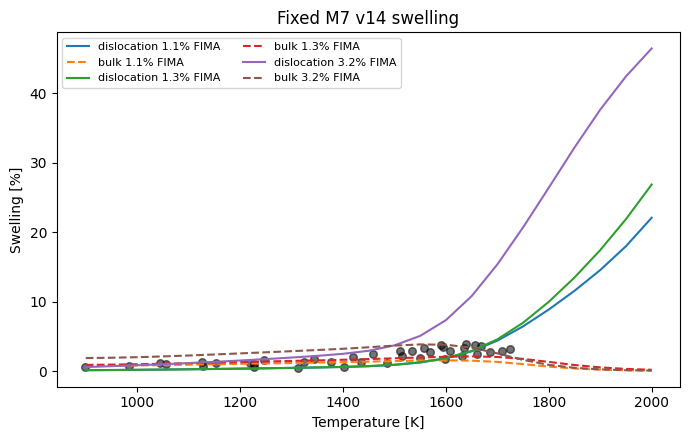

In [6]:
def savefig(name):
    path = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    print(f'saved {path}')

plt.figure(figsize=(7, 4.5))
for bu, rows in series.items():
    plt.plot(TEMPS, [r['swelling_d_percent'] for r in rows], label=f'dislocation {bu}% FIMA')
    plt.plot(TEMPS, [r['swelling_b_percent'] for r in rows], '--', label=f'bulk {bu}% FIMA')
for p in EXP_SWELLING_T:
    if p['burnup'] in BURNUPS_FOR_PLOTS:
        plt.scatter(p['T'], p['swelling'], s=30, color='black', alpha=0.55)
plt.xlabel('Temperature [K]')
plt.ylabel('Swelling [%]')
plt.title('Fixed M7 v14 swelling')
plt.legend(ncol=2, fontsize=8)
savefig('swelling_vs_temperature.png')
plt.show()

saved /home/destro/sciantix-official/UN_model/optuna/M7_v14/fixed_parameter_plots/radius_and_density_1p3FIMA.png


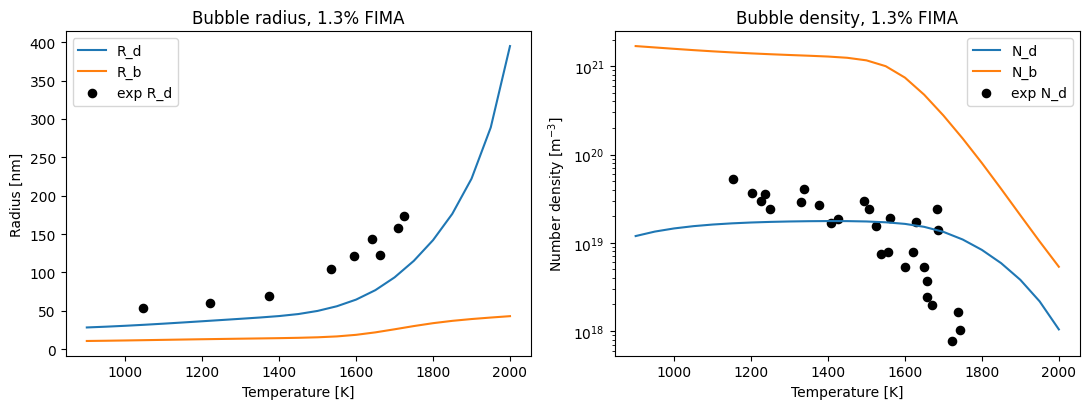

In [7]:
rows = series[1.3]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(TEMPS, [r['Rd_nm'] for r in rows], label='R_d')
axes[0].plot(TEMPS, [r['Rb_nm'] for r in rows], label='R_b')
axes[0].scatter([p['T'] for p in EXP_RD_T_13], [p['R_nm'] for p in EXP_RD_T_13], color='black', s=35, label='exp R_d')
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Radius [nm]')
axes[0].set_title('Bubble radius, 1.3% FIMA')
axes[0].legend()

axes[1].semilogy(TEMPS, [r['Nd'] for r in rows], label='N_d')
axes[1].semilogy(TEMPS, [r['Nb'] for r in rows], label='N_b')
axes[1].scatter([p['T'] for p in EXP_ND_T_13], [p['N'] for p in EXP_ND_T_13], color='black', s=35, label='exp N_d')
axes[1].set_xlabel('Temperature [K]')
axes[1].set_ylabel('Number density [m$^{-3}$]')
axes[1].set_title('Bubble density, 1.3% FIMA')
axes[1].legend()
savefig('radius_and_density_1p3FIMA.png')
plt.show()

saved /home/destro/sciantix-official/UN_model/optuna/M7_v14/fixed_parameter_plots/gas_partition_and_pressure.png


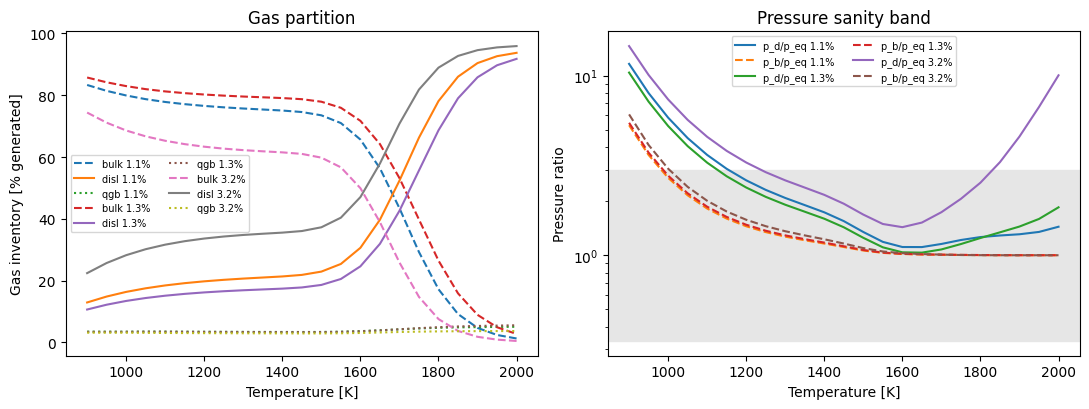

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for bu, rows in series.items():
    axes[0].plot(TEMPS, [r['bulk_gas_percent'] for r in rows], '--', label=f'bulk {bu}%')
    axes[0].plot(TEMPS, [r['dislocation_gas_percent'] for r in rows], label=f'disl {bu}%')
    axes[0].plot(TEMPS, [r['qgb_gas_percent'] for r in rows], ':', label=f'qgb {bu}%')
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Gas inventory [% generated]')
axes[0].set_title('Gas partition')
axes[0].legend(fontsize=7, ncol=2)

for bu, rows in series.items():
    axes[1].semilogy(TEMPS, [r['p_d_over_eq'] for r in rows], label=f'p_d/p_eq {bu}%')
    axes[1].semilogy(TEMPS, [r['p_b_over_eq'] for r in rows], '--', label=f'p_b/p_eq {bu}%')
axes[1].axhspan(1/3, 3, color='0.9', zorder=0)
axes[1].set_xlabel('Temperature [K]')
axes[1].set_ylabel('Pressure ratio')
axes[1].set_title('Pressure sanity band')
axes[1].legend(fontsize=7, ncol=2)
savefig('gas_partition_and_pressure.png')
plt.show()

saved /home/destro/sciantix-official/UN_model/optuna/M7_v14/fixed_parameter_plots/burnup_scan_and_history.png


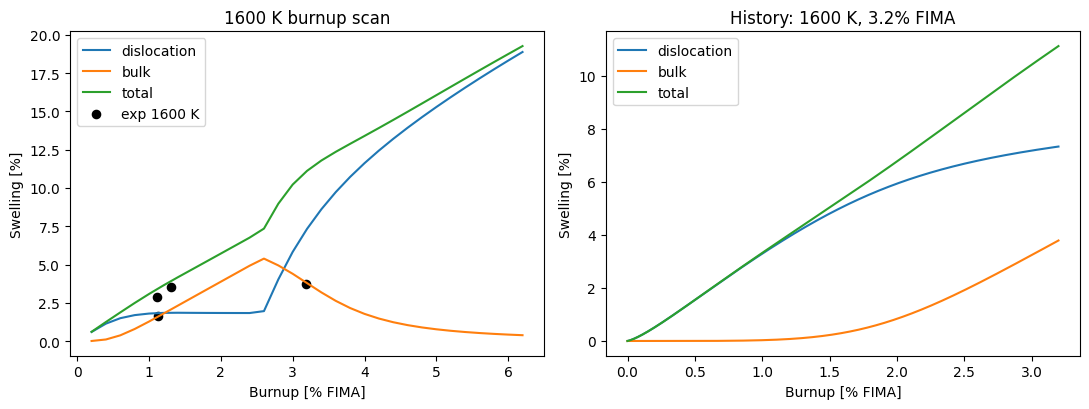

In [9]:
burnups = [round(0.2 + 0.2*i, 2) for i in range(31)]
scan_1600 = [run_point(1600.0, bu, keep_history=False) for bu in burnups]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(burnups, [r['swelling_d_percent'] for r in scan_1600], label='dislocation')
axes[0].plot(burnups, [r['swelling_b_percent'] for r in scan_1600], label='bulk')
axes[0].plot(burnups, [r['swelling_ig_percent'] for r in scan_1600], label='total')
axes[0].scatter([p['burnup'] for p in EXP_SWELLING_BURNUP_1600], [p['swelling'] for p in EXP_SWELLING_BURNUP_1600], color='black', s=35, label='exp 1600 K')
axes[0].set_xlabel('Burnup [% FIMA]')
axes[0].set_ylabel('Swelling [%]')
axes[0].set_title('1600 K burnup scan')
axes[0].legend()

hist = run_point(1600.0, 3.2, keep_history=True)['hist']
axes[1].plot(hist['burnup_percent_fima'], [100*x for x in hist['swelling_d']], label='dislocation')
axes[1].plot(hist['burnup_percent_fima'], [100*x for x in hist['swelling_b']], label='bulk')
axes[1].plot(hist['burnup_percent_fima'], [100*x for x in hist['swelling_ig']], label='total')
axes[1].set_xlabel('Burnup [% FIMA]')
axes[1].set_ylabel('Swelling [%]')
axes[1].set_title('History: 1600 K, 3.2% FIMA')
axes[1].legend()
savefig('burnup_scan_and_history.png')
plt.show()

In [10]:
print(f'All fixed-parameter plots are in: {PLOTS_DIR}')

All fixed-parameter plots are in: /home/destro/sciantix-official/UN_model/optuna/M7_v14/fixed_parameter_plots
